## Checking the validity of the code with prescribed source 

Calculate $|\nabla\hat{h}|$ across the map

In [2]:
include("sup_elliptical.jl")
using Plots
using LinearAlgebra
using SpecialFunctions
using LaTeXStrings

In [35]:
v = 1.5

1.5

In [36]:
A = prescribed_source(3pi/2, 3pi/2, v, 100, true)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:   350684
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:    51308
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    51308
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0000000e+00 8.76e-01 0.00e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 4.0296982775124245e-15 3.5908496014824925e-15; 0.0 0.0 … 1.3789889558394316e-7 1.3112277570844208e-7; … ; 0.0 0.0 … 1.378988155770019e-7 1.3112270242209476e-7; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 9.075372839716558e-15 1.015080270491756e-14; 0.0 0.0 … 5.163785741427204e-7 5.873054544706822e-7; … ; 0.0 0.0 … 5.163786248980126e-7 5.873055185765187e-7; 0.0 0.0 … 0.0 0.0], Any[0.0, 0.03844, 0.07688, 0.11532, 0.15376, 0.1922, 0.23064, 0.26908, 0.30752, 0.34596000000000005  …  18.37432, 18.412760000000002, 18.4512, 18.48964, 18.52808, 18.56652, 18.604960000000002, 18.6434, 18.68184, 18.720280000000002], Any[-19.22, -18.8356, -18.4512, -18.0668, -17.682399999999998, -17.298, -16.9136, -16.5292, -16.1448, -15.760399999999999  …  15.760399999999997, 16.144799999999996, 16.529199999999996, 16.913599999999995, 17.297999999999995,

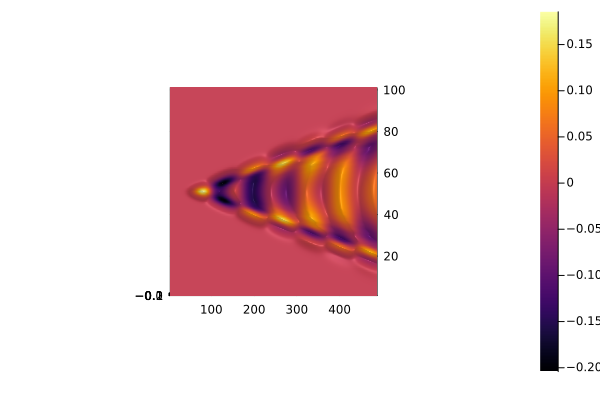

In [37]:
surface(A[3],camera=(0,90))

In [38]:
xl = length(A[3][1,:])
yl = length(A[3][:,1])

mod_grad_real = zeros(yl,xl)
mod_grad_imag = zeros(yl,xl)
mod_grad = zeros(yl,xl)
mod_full = zeros(yl,xl)

for xi in 2:xl-1
    for yi in 2:yl-1
        hx_r = first_centred_x(A[3],A[8],yi,xi)
        hy_r = first_centred_y(A[3],A[9],yi,xi)
        hx_i = first_centred_x(A[4],A[8],yi,xi)
        hy_i = first_centred_y(A[4],A[9],yi,xi)
        mod_grad_real[yi,xi] = sqrt(hx_r^2+hy_r^2)
        mod_grad_imag[yi,xi] = sqrt(hx_i^2+hy_i^2)
        mod_grad[yi,xi] = sqrt(hx_r^2+hx_i^2+hy_r^2+hy_i^2)
        mod_full[yi,xi] = sqrt(A[3][yi,xi]^2+A[4][yi,xi]^2)
    end
end

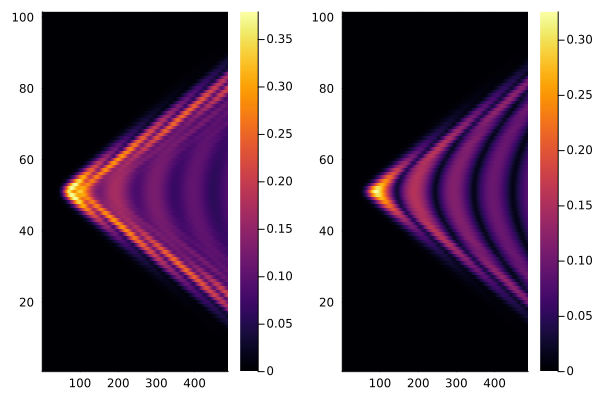

In [39]:
plot(heatmap(mod_grad),heatmap(mod_full))

In [32]:
norm(mod_grad,Inf)/norm(mod_full,Inf)

1.7432525307512725

In [41]:
# remove centre
for xi in 1:length(A[1][1,:])
    for yi in 1:length(A[1][:,1])
        if A[1][yi,xi] != 0
            mod_grad[yi,xi] = 0
            mod_full[yi,xi] = 0
        end
    end
end

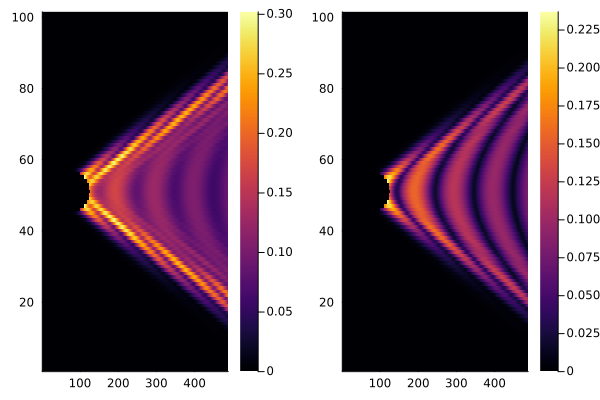

In [42]:
plot(heatmap(mod_grad),heatmap(mod_full))

In [17]:
norm(mod_grad,Inf)/norm(mod_full,Inf)

1.415053983294054

In [21]:
# # run on a bunch of threads in terminal
startv = 1.05
endv = 2.5
vstep = 0.05

max_real = zeros(length(startv:vstep:endv))
max_imag = zeros(length(startv:vstep:endv))
mod_max = zeros(length(startv:vstep:endv))
full = zeros(length(startv:vstep:endv))
vels = startv:vstep:endv

for i in 1:length(vels)
    A = prescribed_source(3pi/2, 3pi/2, vels[i], 100, true,true)

    xl = length(A[3][1,:])
    yl = length(A[3][:,1])

    mod_grad_real = zeros(yl,xl)
    mod_grad_imag = zeros(yl,xl)
    mod_grad = zeros(yl,xl)
    mod_full = zeros(yl,xl)

    for xi in 2:xl-1
        for yi in 2:yl-1
            hx_r = first_centred_x(A[3],A[8],yi,xi)
            hy_r = first_centred_y(A[3],A[9],yi,xi)
            hx_i = first_centred_x(A[4],A[8],yi,xi)
            hy_i = first_centred_y(A[4],A[9],yi,xi)
            mod_grad_real[yi,xi] = sqrt(hx_r^2+hy_r^2)
            mod_grad_imag[yi,xi] = sqrt(hx_i^2+hy_i^2)
            mod_grad[yi,xi] = sqrt(hx_r^2+hx_i^2+hy_r^2+hy_i^2)
            mod_full[yi,xi] = sqrt(A[3][yi,xi]^2+A[4][yi,xi]^2)
        end
    end
    for xi in 1:length(A[1][1,:])
        for yi in 1:length(A[1][:,1])
            if A[1][yi,xi] != 0
                mod_grad[yi,xi] = 0
                mod_full[yi,xi] = 0
            end
        end
    end
    mod_max[i] = norm(mod_grad,Inf)
    max_real[i] = norm(mod_grad_real,Inf)
    max_imag[i] = norm(mod_grad_imag,Inf)
    full[i] = norm(mod_grad,Inf)/norm(mod_full,Inf)
    print("v = ", vels[i],"\t")
end



v = 1.05	v = 1.1	v = 1.15	v = 1.2	v = 1.25	v = 1.3	v = 1.35	v = 1.4	v = 1.45	v = 1.5	v = 1.55	v = 1.6	v = 1.65	v = 1.7	v = 1.75	v = 1.8	v = 1.85	v = 1.9	v = 1.95	v = 2.0	v = 2.05	v = 2.1	v = 2.15	v = 2.2	v = 2.25	v = 2.3	v = 2.35	v = 2.4	v = 2.45	v = 2.5	

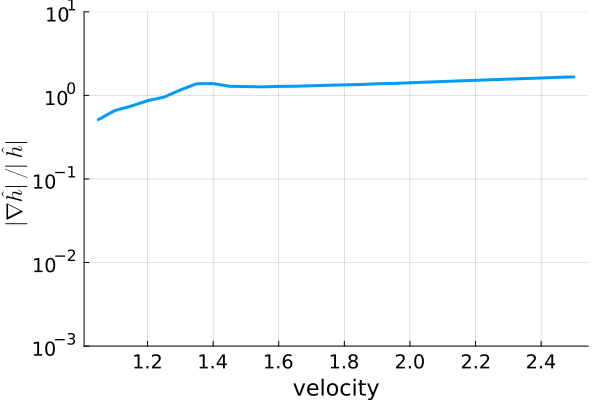

In [25]:
pl = plot(vels,full,yscale=:log10,ylims=[0.001,10],
    xlabel="velocity",ylabel=L"|\nabla\hat{h}\,|/|\hat{h}\,|",legend=false,
    linewidth=3, tickfontsize=13,gridalpha=0.25, 
    labelfontsize=15)

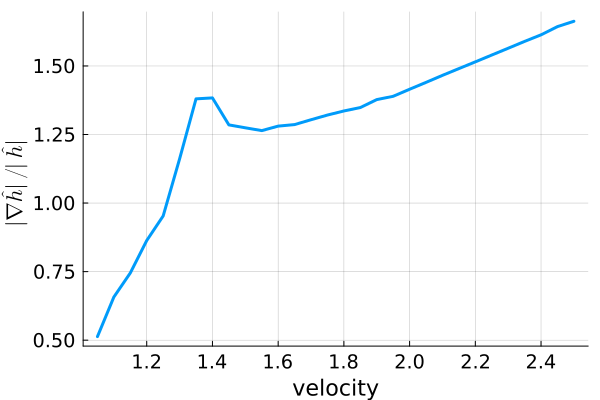

In [26]:
pl1 = plot(vels,full,
    xlabel="velocity",ylabel=L"|\nabla\hat{h}\,|/|\hat{h}\,|",legend=false,
    linewidth=3, tickfontsize=13,gridalpha=0.25, 
    labelfontsize=15)